In [209]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd

# ---------------------------------------------------------------
# 1.1  Helper – Load Experiment from .npz files
# ---------------------------------------------------------------

def load_experiment(fp: Path) -> dict:
    """
    Load a *.npz file created by the pre-processing notebook
    and return a dict suitable for numerical analysis.

    Returns
    -------
    sample : dict
        ├─ "signals" : pd.DataFrame
        │             index = time [s]
        │             columns = time, 
        │                       incident_raw, reflected_raw, transmitted_raw,
        │                       incident_weight, reflected_weight, transmitted_weight   (whichever exist)
        ├─ "L0_mm"   : float  (if present)
        ├─ "A0_mm2"  : float  (if present)
        └─ "D0_mm"   : float  (if present)
    """
    with np.load(fp, allow_pickle=False) as data:
        # ---------- continuous signals -------------------------------------
        required = ["time"]
        continuous = [
            "time", "incident_raw", "reflected_raw", "transmitted_raw",
            "incident_weight", "reflected_weight", "transmitted_weight",
        ]
        # sanity check
        for key in required:
            if key not in data:
                raise KeyError(f"{key} missing from {fp.name}")

        df   = pd.DataFrame(dtype=np.float32)

        for key in continuous:
            if key in data:
                df[key] = data[key].astype(np.float32)

        sample: dict[str, object] = {"signals": df}

        # ---------- specimen / bar geometry --------------------------------
        for gk in ("L0_mm", "A0_mm2", "D0_mm"):
            if gk in data:
                # np.load can return 0-D arrays; convert to python float
                sample[gk] = float(np.asarray(data[gk]))

    return sample

# ---------------------------------------------------------------
# 1.2  Helper – cumulative (rectangle-rule) integral
# ---------------------------------------------------------------
def cumulative_integral(y: np.ndarray, dt: np.ndarray) -> np.ndarray:
    """
    Rectangle-rule ∫ y dt from t=0 to t_i, same shape as y.
    Assumes y.shape == dt.shape == (T,) or (B,T).
    """
    dt = np.diff(time, axis=-1)
    pad = np.zeros_like(time[..., :1])
    dt  = np.concatenate([dt, pad], axis=-1)   # pad so shapes match
    return np.cumsum(y * dt, axis=-1)


..\pinn_dataset\SS316\npz\DKS_20250507_SS316_LAB_RT_026.npz


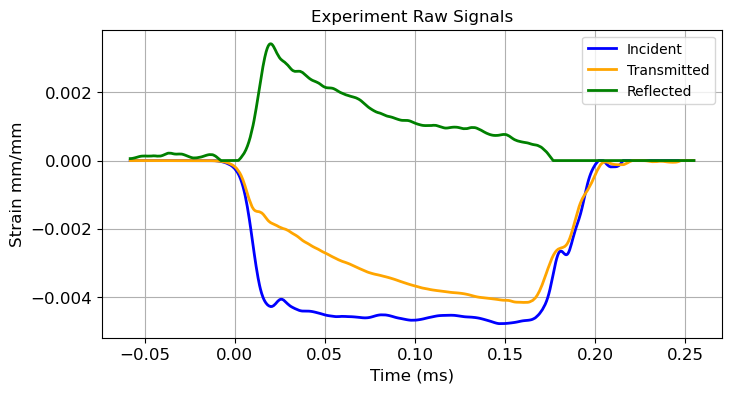

Specimen Cross-Section: 31.570 mm^2
Specimen Length: 6.390 mm


In [190]:
# --- 2.1  Load example experiment -------------------------------
data_dir = Path("../pinn_dataset/SS316/npz")
files    = sorted(data_dir.glob("*.npz"))
idx = 5

data = load_experiment(files[idx]) # change to desired idx
print(files[idx])

# quick data inspection
plt.figure(figsize=(8,4))
plt.plot(data["signals"]["time"], data["signals"]["incident_raw"], label = "Incident", lw = 2, c = "b")
plt.plot(data["signals"]["time"], data["signals"]["transmitted_raw"], label = "Transmitted", lw = 2, c = "orange")
plt.plot(data["signals"]["time"], data["signals"]["reflected_raw"], label = "Reflected", lw = 2, c = "g")
plt.title("Experiment Raw Signals")
plt.xlabel("Time (ms)", fontsize = 12) ; plt.ylabel("Strain mm/mm", fontsize = 12)
plt.xticks(fontsize = 12) ; plt.yticks(fontsize = 12)
plt.grid() ; plt.legend()
plt.show()

print(f"Specimen Cross-Section: {data['A0_mm2']:.3f} mm^2")
print(f"Specimen Length: {data['L0_mm']:.3f} mm")

In [191]:
# --- 2.2  Specimen / Bar constants -------------------------------

# Specimen Constants
E_s = 193.974     # specimen elastic modulus GPa 
beta   = 0.95     # adiabatic fraction (specimen)
rho_s  = 7.6e-3   # kg / mm^3 
Cp_s   = 0.46     # kN·mm/kg·K
T_melt = 1673.0   # K
T_room = 298.0    # K

# Bar Constants
E_bar  = 199.99   # GPa
c_bar  = 4953.321 # mm/ms
rho_bar= 7.8e-6   # kg/mm^3
bar_cross = 71.26 # mm²

# --- 2.3  Initial JC-Parameters (literature, guess or previous FEA card) --
A=0.198           # GPa     
B=1.048           # GPa
n=0.254013        
C=0.005
m=0.5

In [192]:
# --- 3.1  Experiment array unpack and dt -------------------------------
time   = data["signals"]["time"].values
inc    = data["signals"]["incident_raw"].values
ref    = data["signals"]["reflected_raw"].values
tra    = data["signals"]["transmitted_raw"].values

w_inc = data["signals"]["incident_weight"].values
w_ref = data["signals"]["reflected_weight"].values
w_tra = data["signals"]["transmitted_weight"].values

L0_mm  = data["L0_mm"]
A0_mm2 = data["A0_mm2"]

dt = np.median(np.diff(time))
print(f"Experiment dt: {dt:.3e} ms")

Experiment dt: 1.252e-05 ms


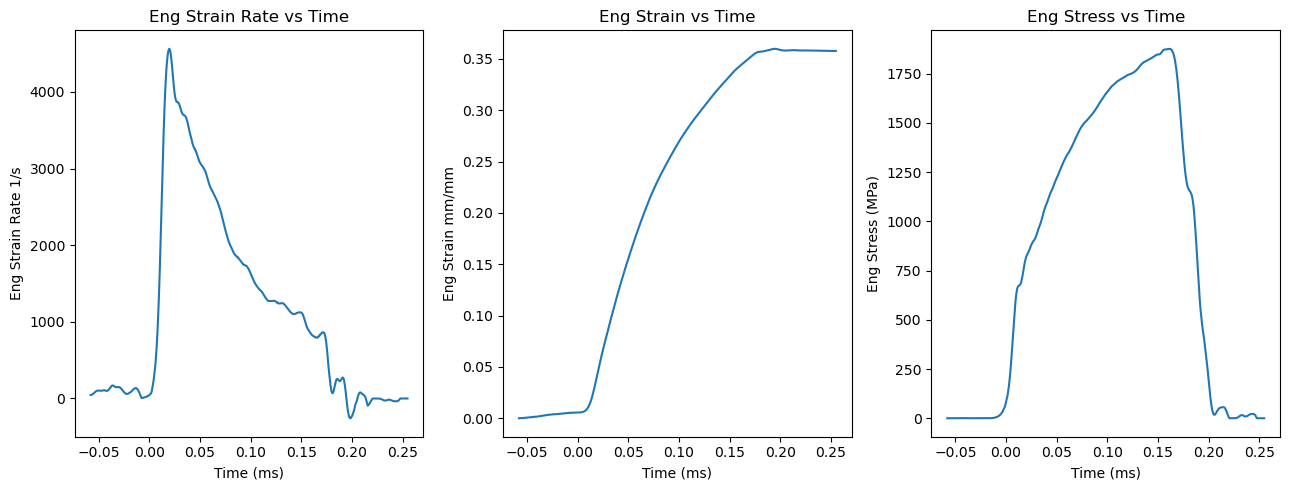

In [211]:
# --- 3.2 Experimental derived curves --------------------------------
eps_dot_exp = (c_bar / L0_mm) * (inc - ref - tra)                          # Engineering Strain Rate from 3-Wave Analysis
eps_exp     = (c_bar / L0_mm) * cumulative_integral(inc - ref - tra, time)   # Engineering Strain from 3-Wave Analysis
sig_1w_exp  = E_bar * (bar_cross / A0_mm2) * tra                           # Engineering Stress from 1-Wave Analysis 


fig, [ax1, ax2, ax3] = plt.subplots(nrows=1, ncols=3, figsize=(13,5))
ax1.plot(time, -eps_dot_exp*1000)
ax1.set_xlabel("Time (ms)") ; ax1.set_ylabel("Eng Strain Rate 1/s")
ax1.set_title("Eng Strain Rate vs Time")
ax2.plot(time, -eps_exp)
ax2.set_xlabel("Time (ms)") ; ax2.set_ylabel("Eng Strain mm/mm")
ax2.set_title("Eng Strain vs Time")
ax3.plot(time, -sig_1w_exp*1E3)
ax3.set_xlabel("Time (ms)") ; ax3.set_ylabel("Eng Stress (MPa)")
ax3.set_title("Eng Stress vs Time")
plt.tight_layout()
plt.show()

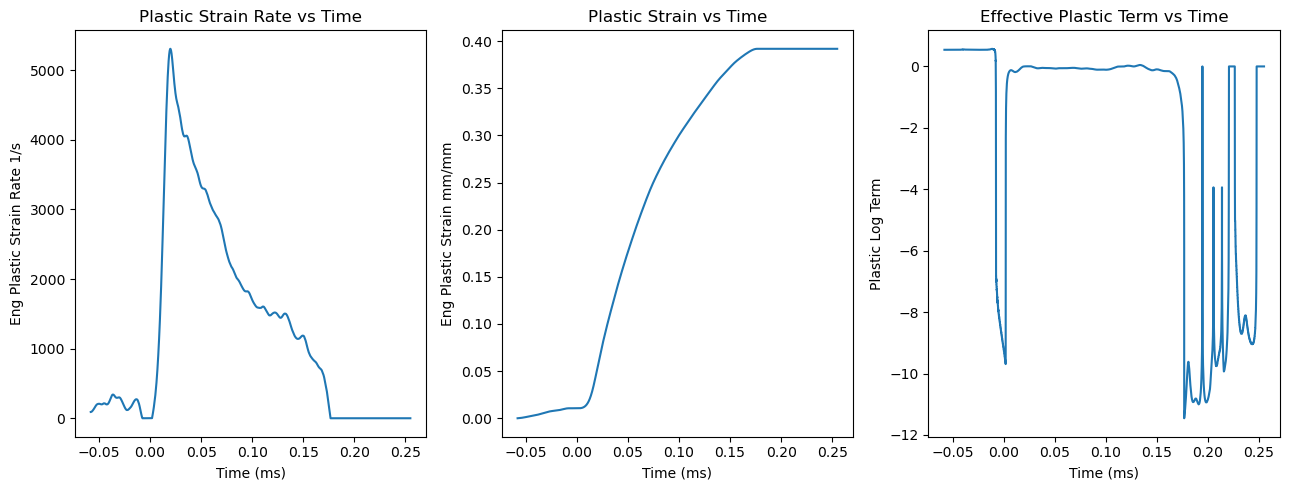

In [212]:
# --- 3.2 Determine Plastic Strain from Experiment -------------------
eps_pl_dot_exp = 2.0 * c_bar / L0_mm * ref                           # Engineering Plastic Strain Rate
eps_pl_exp     = cumulative_integral(np.abs(eps_pl_dot_exp), time)     # Engineering Plastic Strain 

# --- 3.2 Determine Effective Plastic Strain Term for JC-Model -------
eps_floor = 1e-9  # small positive to avoid log(0), Fail-safe for ln() when dividing by zero
num = np.abs(eps_pl_dot_exp) / np.max(np.abs(eps_pl_dot_exp)) + 1e-6
den = np.abs(eps_dot_exp) / np.max(np.abs(eps_dot_exp)) + 1e-6
#num = np.abs(eps_pl_dot_exp) / np.max(np.abs(eps_pl_dot_exp)) 
#den = np.abs(eps_dot_exp) / np.max(np.abs(eps_dot_exp)) 
eps_log_term = np.log(num / den)           # Plastic term for JC-Model
eps_log_term = np.nan_to_num(eps_log_term, nan=0.0, posinf=0.0, neginf=0.0)
     

fig, [ax1, ax2, ax3] = plt.subplots(nrows=1, ncols=3, figsize=(13,5))
ax1.plot(time, eps_pl_dot_exp*1000)
ax1.set_xlabel("Time (ms)") ; ax1.set_ylabel("Eng Plastic Strain Rate 1/s")
ax1.set_title("Plastic Strain Rate vs Time")
ax2.plot(time, eps_pl_exp)
ax2.set_xlabel("Time (ms)") ; ax2.set_ylabel("Eng Plastic Strain mm/mm")
ax2.set_title("Plastic Strain vs Time")
ax3.plot(time, eps_log_term)
ax3.set_xlabel("Time (ms)") ; ax3.set_ylabel("Plastic Log Term")
ax3.set_title("Effective Plastic Term vs Time")
plt.tight_layout()
plt.show()

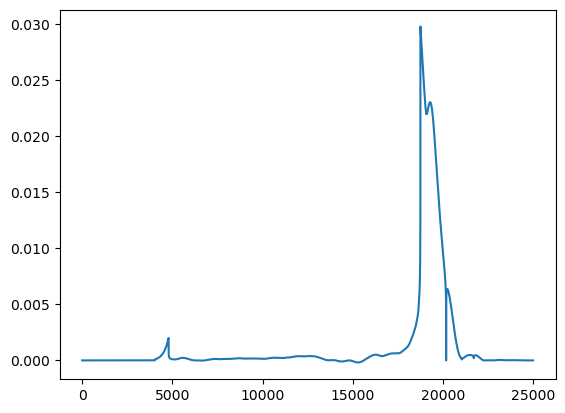

In [201]:
plt.plot(w_tra * eps_log_term)
plt.show()

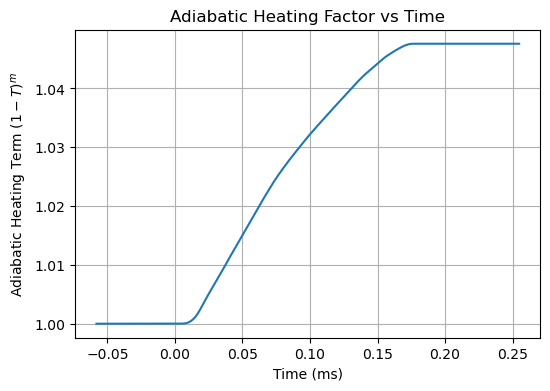

In [213]:
# --- 3.3 Determine Adiabatic Heating Term for JC-Model --------------
alpha = beta / (rho_s * Cp_s * (T_melt - T_room))   # 1 / GPa

# cumulative integral (rectangle rule)
t_star = alpha * cumulative_integral(sig_1w_exp * eps_pl_dot_exp, time)   # Adiabatic Heating Factor T* for JC-Model

plt.figure(figsize=(6,4))
plt.plot(time, (1-t_star)**m)
plt.title("Adiabatic Heating Factor vs Time")
plt.xlabel("Time (ms)") ; plt.ylabel("Adiabatic Heating Term $(1 - T)^m$")
plt.grid() ; plt.show()

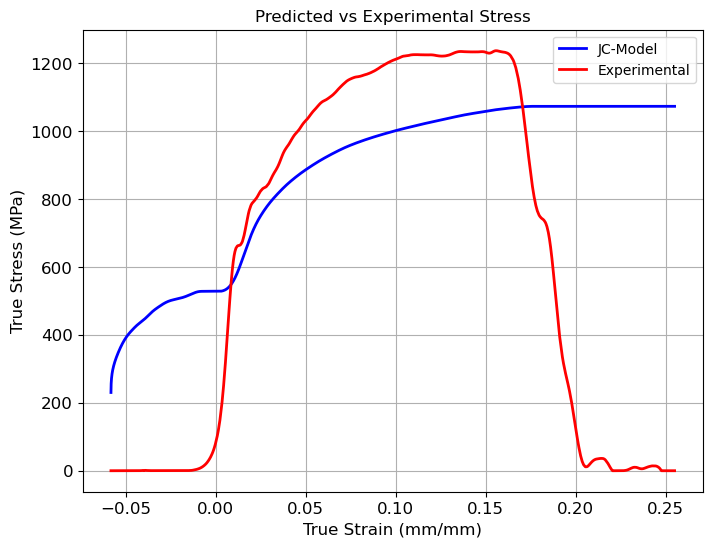

In [214]:
# --- 4.1 Determine Johnson-Cook Strength ----------------------------
sig_jc_pred = (A + B * eps_pl_exp**n) * (1 + C * - (w_tra * eps_log_term)) * (1 - t_star)**m     # Johnson-Cook Model (JC-Model)

# --- 4.2 Determine  Experimental True Stress / True Strain ----------
true_stress = sig_1w_exp * (1 + eps_exp)
true_strain = np.log(1 + eps_exp)

plt.figure(figsize=(8,6))
plt.plot(time,  sig_jc_pred*1e3, label = "JC-Model",     lw = 2, c = "b")
plt.plot(time, -true_stress*1e3, label = "Experimental", lw = 2, c = "r")
plt.xlabel("True Strain (mm/mm)", fontsize = 12); plt.ylabel("True Stress (MPa)", fontsize = 12)
plt.title("Predicted vs Experimental Stress")
plt.xticks(fontsize=12) ; plt.yticks(fontsize=12)
plt.grid() ; plt.legend()
plt.show()

In [215]:
np.unique(np.isfinite(sig_jc_pred))



array([ True])

RMSE loss metric: 0.210


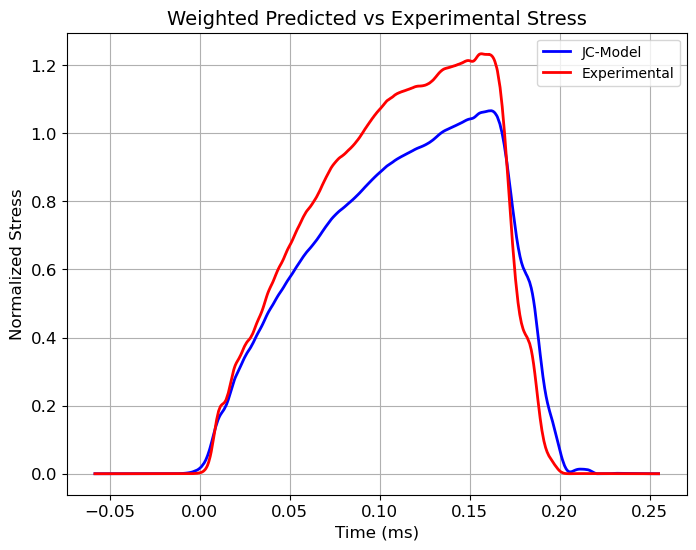

In [216]:
# --- 5.1 Define Loss Metric Used in PINN-----------------------------
def weighted_rmse(y_pred: np.ndarray,
                  y_true: np.ndarray,
                  w: np.ndarray) -> float:
    """RMSE with pre-computed weights."""
    resid2 = w * (y_pred - y_true)**2
    return np.sqrt(resid2.sum() / w.sum())

# --- 5.1 Apply Weights and Calculate Loss ---------------------------

# Using the transmitted Tukey-window weight
w_sig = w_tra / np.max(np.abs(w_tra))                 # normalise to [0,1]

rmse_val = weighted_rmse(-sig_jc_pred, true_stress, w_sig)   # Loss used in PINN
print(f"RMSE loss metric: {rmse_val:.3f}")

plt.figure(figsize=(8,6))
plt.plot(time, -sig_jc_pred * w_sig, label = "JC-Model",     lw =2 , c = "b")
plt.plot(time,  true_stress * w_sig, label = "Experimental", lw =2,  c = "r")
plt.title("Weighted Predicted vs Experimental Stress", fontsize=14)
plt.xlabel("Time (ms)", fontsize=12) ; plt.ylabel("Normalized Stress", fontsize=12)
plt.xticks(fontsize=12) ; plt.yticks(fontsize=12)
plt.grid() ; plt.legend()
plt.show()